# Diagnostics and Visualizations

There are many factors that influence whether training succeeds and how well an amortized approximator captures the true posterior. Systematically checking the results and diagnosing potential issues is therefore an essential part of every amortized Bayesian workflow.

This guide walks through the key diagnostic steps — from inspecting the training loss to checking calibration on held-out simulations. All diagnostics described below operate under **known ground truth**, i.e., using data whose parameters were drawn from the prior. This *in silico* setting is the ideal starting point: if everything looks good here, you can proceed to real-data inference with increased confidence.

In [ ]:
import bayesflow as bf

In [ ]:
workflow = bf.BasicWorkflow(
    inference_network=bf.networks.FlowMatching(),
    inference_variables=["parameters"],
    inference_conditions=["observables"],
    simulator=bf.simulators.SIR()
)

history = workflow.fit_online(epochs=30, batch_size=64, num_batches_per_epoch=200)

## Convergence

The training loss is the first thing to inspect after training. While a low loss alone does not guarantee that the approximator is doing a good job, it can reveal clear problems early on. Use {py:func}`bayesflow.diagnostics.loss` to visualize both the training and validation curves.

A healthy loss curve decreases smoothly and then plateaus near the end of training. The following patterns are warning signs:

- **Growing gap between training and validation loss** — overfitting. The network memorizes training simulations rather than learning the posterior structure. Remedy: increase the simulation budget, reduce network capacity, or switch to online training.
- **Loss still visibly decreasing at the final epoch** — training has not yet converged. More epochs are needed.
- **NaN spikes or explosive loss values** — numerical instability, often caused by pathological simulator outputs or missing normalization.

We therefore recommend always supplying validation data during training so that both curves are visible at a glance. For offline or disk training, pass `validation_data` to each `fit_*` call.

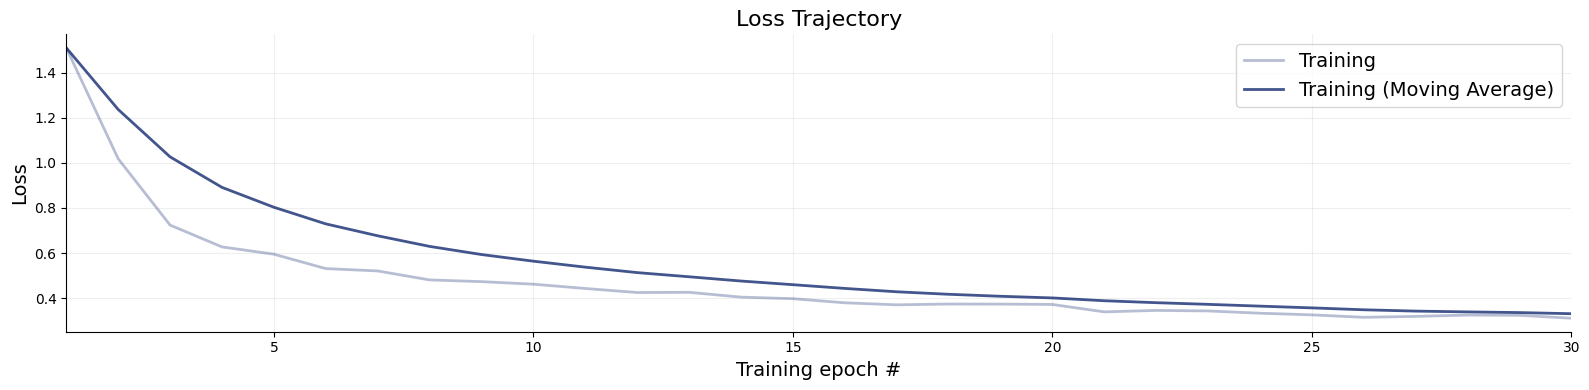

In [3]:
f = bf.diagnostics.loss(history)

## Model Verification

Model verification — sometimes called *in silico* validation — assesses the quality of the posterior approximation before any real data are involved. The idea is to simulate parameter–data pairs from the joint prior-predictive distribution, run inference on the simulated observations, and check whether the resulting posteriors behave as they should (correct calibration, good recovery). This isolates problems with the approximator — insufficient capacity, too little training, etc. — independently of whether the assumed model is appropriate for the observed data.

In traditional Bayesian workflows, model verification is computationally expensive because it requires refitting the model for each simulated dataset. **BayesFlow** makes this essentially free: once the network is trained, all held-out simulations can be evaluated in a single forward pass. The subsections below cover three complementary aspects of model verification.

In [ ]:
# First, simulate fresh test data and then obtain 1000 posterior drws for each test data instance
test_data = workflow.simulate(100)

samples = workflow.sample(num_samples=1000, conditions=test_data)

### Recovery

Each panel of the recovery plot shows the posterior median (a point estimate) against the true parameter value across many held-out simulated datasets. Points falling on the diagonal indicate perfect recovery; the vertical bars represent 90% posterior credible intervals, whose width reflects estimation uncertainty.

Systematic deviations from the diagonal (curved or offset point clouds) reveal posterior bias. Uniformly wide intervals signal that the data are only weakly informative for that parameter under the current model and prior. {py:func}`~bayesflow.diagnostics.recovery` generates this plot.

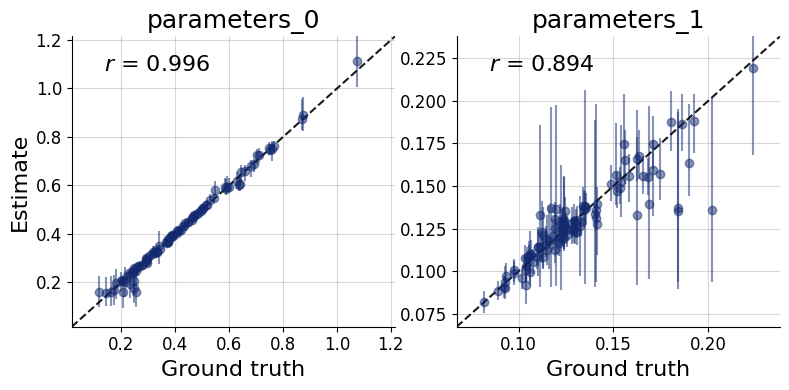

In [5]:
f = bf.diagnostics.recovery(samples, test_data, figsize=(8, 4))

## Simulation-based Calibration (SBC)

Simulation-based calibration (SBC) provides a rigorous check of posterior accuracy without requiring the ground-truth posterior. The key insight is that, under a well-calibrated approximator, the rank of the true parameter value among posterior draws should be *uniformly distributed* from 1 to `num_samples`. Two complementary graphical representations are available:

- **SBC histogram** ({py:func}`~bayesflow.diagnostics.calibration_histogram`): plots rank histograms with simultaneous confidence bands. Bars should remain within the band for a well-calibrated approximator. The bands are conservatively wide, however, which limits sensitivity.
- **SBC ECDF** ({py:func}`~bayesflow.diagnostics.calibration_ecdf`): plots the empirical CDF of posterior ranks against the uniform diagonal with tighter, more statistically precise confidence bands. This is the preferred diagnostic.

**Interpreting the ECDF plot:** An ECDF close to the diagonal indicates good calibration. Lines consistently *above* the diagonal signal an **overconfident** posterior — credible intervals are too narrow, so the true value escapes them too often. Lines consistently *below* the diagonal signal an **underconfident** posterior — intervals are too wide. [This SBC interpretation guide by Martin Modrák](https://hyunjimoon.github.io/SBC/articles/rank_visualizations.html) provides detailed practical examples of both patterns and their implications.

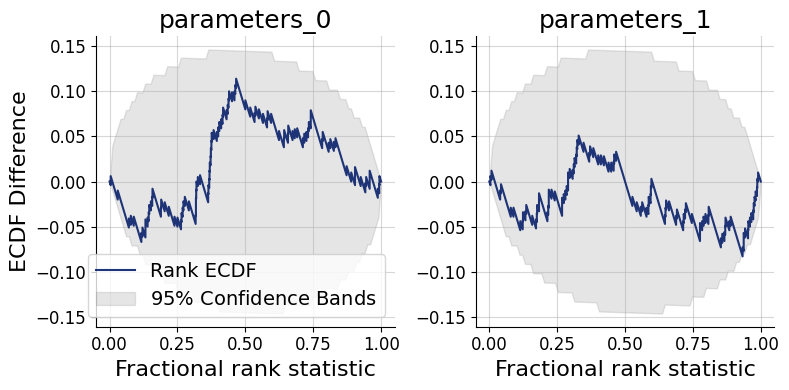

In [6]:
f = bf.diagnostics.calibration_ecdf(samples, test_data, figsize=(8, 4))

Coverage plots offer a more direct view of the same calibration property: they show the fraction of held-out true parameter values that fall within nominal credible intervals (e.g., 50%, 80%, 95%). A well-calibrated approximator produces empirical coverage that tracks the nominal level.

- **Under-coverage** (points below the diagonal): credible intervals are too narrow — the posterior is overconfident.
- **Over-coverage** (points above the diagonal): credible intervals are too wide — the posterior is underconfident.

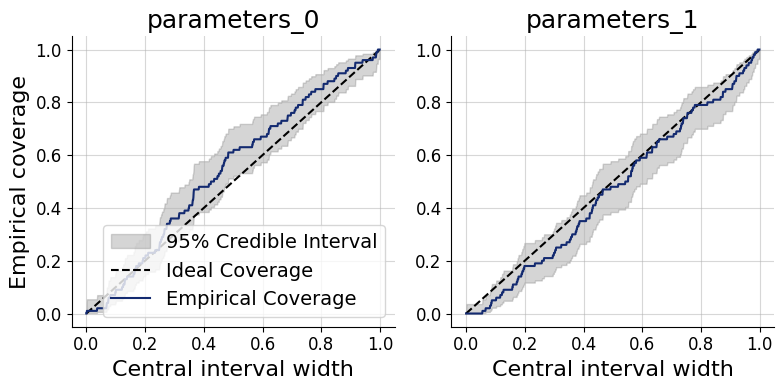

In [8]:
f = bf.diagnostics.coverage(samples, test_data, figsize=(8, 4))

## Posterior Contraction and z-Score

These two scores characterize *how much* and *how accurately* the data update the prior for each parameter:

- **Posterior contraction** (x-axis): the fraction by which the posterior variance has shrunk relative to the prior variance. Values near 0 mean the data carry little information about that parameter; values near 1 indicate near-complete information gain.
- **Posterior z-score** (y-axis): the standardized deviation between the posterior mean and the true parameter value. A distribution symmetric around 0 indicates an unbiased posterior; systematic shifts away from 0 indicate bias.

The **ideal region is the middle-right corner**: high contraction (the data are informative) combined with z-scores distributed around 0 (the posterior is accurate). Parameters clustered in the bottom-left corner are weakly identified by the data. High contraction paired with large absolute z-scores is a sign of overconfidence — the posterior collapses around the wrong value. The {py:func}`~bayesflow.diagnostics.z_score_contraction` function produces this combined plot.

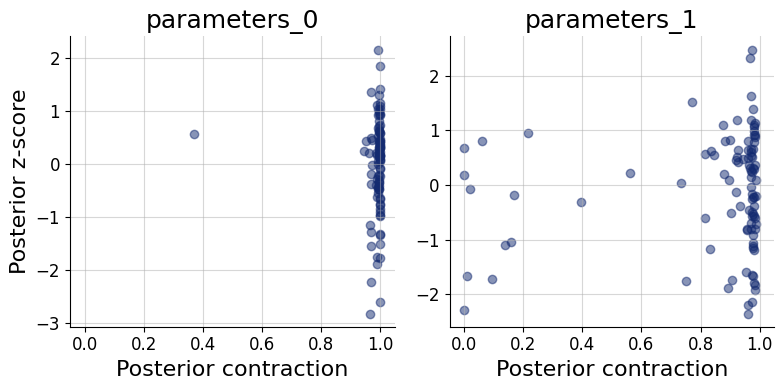

In [9]:
f = bf.diagnostics.z_score_contraction(samples, test_data, figsize=(8, 4))

All of the above diagnostics can also be summarized numerically. `compute_default_diagnostics` computes standardized metrics: including NRMSE (recovery quality), the Log gamma statistic (summary of the ECDF plot), expected calibration error (ECE), and posterior contraction.

In [10]:
table = workflow.compute_default_diagnostics(samples=samples, test_data=test_data)
table

,parameters_0,parameters_1
NRMSE,0.042547,0.215014
Log Gamma,2.312119,0.739678
Calibration Error,0.046053,0.034737
Posterior Contraction,0.998542,0.969975


## Posterior Inference

For a more detailed look at the inferred posterior, {py:func}`~bayesflow.diagnostics.pairs_posterior` produces a corner-style pairs plot showing all one- and two-dimensional marginal distributions for a single dataset. This can reveal parameter correlations and multimodality that marginal summary statistics may miss.

In the simulated-data setting, the true parameter values can be overlaid on the plot to verify visually that the posterior mass is centered near the ground truth.

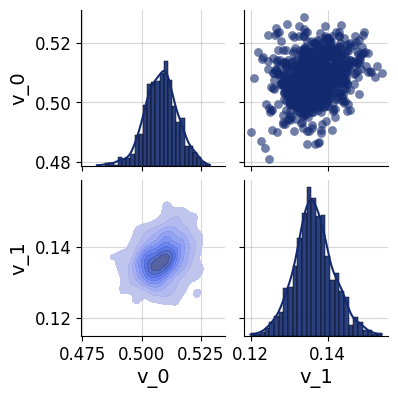

In [11]:
which = 5
f = bf.diagnostics.pairs_posterior(samples["parameters"][which], height=2)

## Posterior Predictive Checks

Posterior predictive checks (PPCs) assess whether the fitted model can reproduce the key features of the observed data. The idea is to draw parameter samples from the posterior and pass each one back through the simulator to generate *replicated* datasets. If the model is adequate, the distribution of replicated datasets should be compatible with the actual observations.

Unlike the simulation-based diagnostics above, **PPCs depend heavily on the data and the scientific question at hand** — there is no universal pass/fail criterion. What to compare (summary statistics, time-series traces, histograms, spatial patterns, etc.) must be chosen with domain knowledge. A common rule of thumb is to use 50 posterior draws for visual PPCs, which is enough to gauge systematic discrepancies without excessive compute.

The general workflow is:

1. Draw `num_reps` parameter samples from the approximate posterior for a chosen observed dataset.
2. Pass each sample through the simulator to obtain a replicated observation via `workflow.simulate`.
3. Compare the distribution of replicated observations against the actual observation using a visualization appropriate for your data type.

The code below demonstrates this resimulation workflow for the SIR simulator. The final visualization step (marked `# Do something...`) should be tailored to the structure and scale of your own data — for instance, overlaying posterior-predictive trajectories on the observed time series, or comparing summary statistics such as the peak infection count.

In [12]:
import matplotlib.pyplot as plt
import numpy as np

In [13]:
resims = []
num_reps = 50

for s in samples["parameters"][which, :num_reps]:
    resims.append(workflow.simulate(1, parameters=s)["observables"].squeeze())

resims = np.array(resims)

# Do something...